## **Setup**

In [1]:
# Notebook autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Path setup
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [3]:
# Libraries
import os as os
import json as json
import torch
import matplotlib.pyplot as plt

# Local
from chatGnT.config import CFG, ensure_dirs
from chatGnT.data import load, preprocess, tokenize, dataloaders
from chatGnT.models import train

# Setup
ensure_dirs(CFG)

## **Load Tokens & Vocabs**

In [4]:
with open(CFG.models_dir / "tokens_mt.json", "r") as f:
    tokens_mt = json.load(f)
with open(CFG.models_dir / "vocab_mt_amt.json", "r") as f:
    vocab_amt = json.load(f)
with open(CFG.models_dir / "vocab_mt_ingred.json", "r") as f:
    vocab_ingred = json.load(f)

inv_vocab_amt, inv_vocab_ingred = tokenize.invert_vocab_mt(vocab_amt, vocab_ingred)
tokens_padded = tokenize.encode_tokens_mt(tokens_mt, vocab_amt, vocab_ingred)

In [5]:
print("Amount vocab ntokens:", len(vocab_amt))
print("First 6:", list(vocab_amt.items())[:6])
print("Last 3:", list(vocab_amt.items())[-3:])

print("Ingredient vocab ntokens:", len(vocab_ingred))
print("First 6:", list(vocab_ingred.items())[:6])
print("Last 3:", list(vocab_ingred.items())[-3:])

Amount vocab ntokens: 105
First 6: [('<amt>0.021 part</amt>', 1), ('<amt>0.042 part</amt>', 2), ('<amt>0.083 part</amt>', 3), ('<amt>0.167 glass</amt>', 4), ('<amt>0.167 part</amt>', 5), ('<amt>0.188 part</amt>', 6)]
Last 3: [('<amt>whole</amt>', 103), ('<pad>', 0), ('<end>', 104)]
Ingredient vocab ntokens: 278
First 6: [('<ingred>151-proof-rum</ingred>', 1), ('<ingred>7-up</ingred>', 2), ('<ingred>absinthe</ingred>', 3), ('<ingred>absolut-citron</ingred>', 4), ('<ingred>absolut-kurant</ingred>', 5), ('<ingred>absolut-peppar</ingred>', 6)]
Last 3: [('<ingred>yukon-jack</ingred>', 276), ('<pad>', 0), ('<end>', 277)]


In [6]:
# Unzip the padded tokens
amt_seqs, ingred_seqs = zip(*tokens_padded)

# Convert to tensors
amt_tensor = torch.tensor(amt_seqs, dtype=torch.long)
ingred_tensor = torch.tensor(ingred_seqs, dtype=torch.long)

# Check shape: (num_recipes, seq_len)
print(amt_tensor.shape, ingred_tensor.shape)

torch.Size([478, 10]) torch.Size([478, 10])


## **Model Config**

In [7]:
config = {
    # model architecture
    "ntoken_amt": len(vocab_amt),
    "ntoken_ingred": len(vocab_ingred),
    "ninp": 32,  # embed size
    "nhead": 2,
    "nhid": 64,  # feed forward size
    "nlayers": 2,
    "model_version": "multi_task",
    "batch_size": 16,

    # training setup
    "learning_rate": 5e-4,
    "weight_decay": 1e-3,

    # scheduler
    "scheduler_type": "reduce_on_plateau",  # "step" or "reduce_on_plateau"
    # reduce on plateau scheduler settings
    "scheduler_factor": 0.5,
    "scheduler_patience": 4,

    # token details
    "pad_id_amt": vocab_amt["<pad>"],
    "pad_id_ingred": vocab_ingred["<pad>"],

    # dataloaders
    "split": 0.85,
    "seed": 42,

    # epochs, early stopping, & logs
    "epochs": 500,
    "early_stop": 10,
    "log_interval": 6
}

## **Train Model**

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

result = train.run_training(
    config,
    {
        "amt_tensor": amt_tensor,
        "ingred_tensor": ingred_tensor,
    },
    device,
)

best_model = result["best_model"]
train_losses = result["train_losses"]
val_losses = result["val_losses"]
gradient_magnitudes = result["gradient_magnitudes"]


/Users/slacksa/repos/chatGnT/src/chatGnT/models/transformer.py:68: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)


Epoch 1 | Batch 6 | LR 0.000500 | Loss 12.0024 | PPL 163144.07 | Time 0.11s
Epoch 1 | Batch 12 | LR 0.000500 | Loss 10.1915 | PPL 26676.55 | Time 0.03s
Epoch 1 | Batch 18 | LR 0.000500 | Loss 10.0411 | PPL 22949.65 | Time 0.03s
Epoch 1 | Batch 24 | LR 0.000500 | Loss 9.9042 | PPL 20015.06 | Time 0.03s
Epoch 1 | Batch 25 | LR 0.000500 | Loss 9.9621 | PPL 21207.22 | Time 0.00s
-----------------------------------------------------------------------------------------
Epoch 1 | Val Loss: 9.5263 | Time 0.20929694175720215 | Val PPL: 13715.78
-----------------------------------------------------------------------------------------
Epoch 2 | Batch 6 | LR 0.000500 | Loss 11.3144 | PPL 81996.86 | Time 0.04s
Epoch 2 | Batch 12 | LR 0.000500 | Loss 9.5881 | PPL 14590.04 | Time 0.03s
Epoch 2 | Batch 18 | LR 0.000500 | Loss 9.3711 | PPL 11744.05 | Time 0.03s
Epoch 2 | Batch 24 | LR 0.000500 | Loss 9.2277 | PPL 10174.74 | Time 0.03s
Epoch 2 | Batch 25 | LR 0.000500 | Loss 9.1668 | PPL 9573.59 | Time 

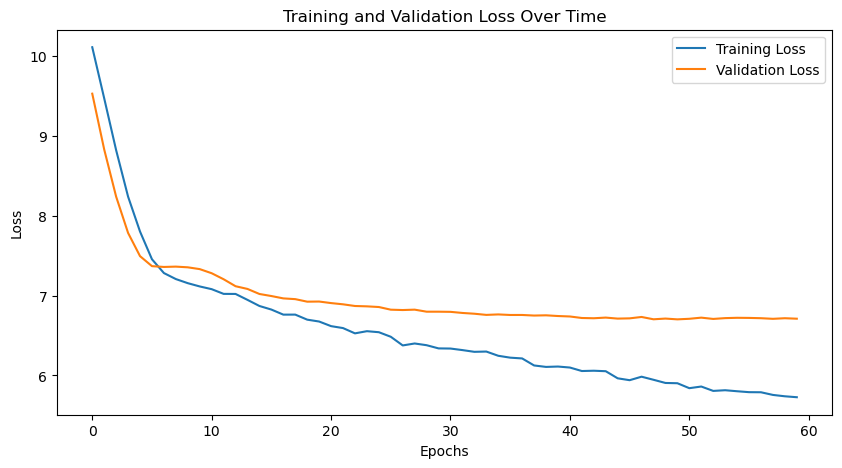

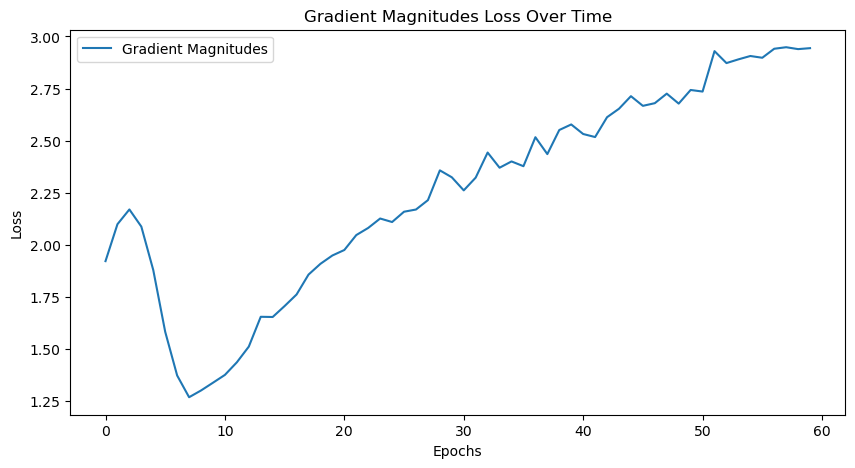

In [9]:
train.plot_training_history(train_losses, val_losses, gradient_magnitudes)


In [10]:
train.save_artifacts_mt(best_model, config, vocab_amt, vocab_ingred, train_losses, val_losses)
